In [ ]:
# pip install openai

# 환경변수 설정

In [ ]:
# .env  환경변수 파일 생성
# OPENAI_API_KEY="sk-proj-****"

In [ ]:
from dotenv import load_dotenv
load_dotenv()   # 기본적으로 .env 파일의 환경변수를 등록. 성공하면 True 리턴

True

In [ ]:
# 확인
import os
os.environ.get("OPENAI_API_KEY")[:20]

'sk-proj-iKU13YeoxNgF'

In [ ]:
from openai import OpenAI

In [ ]:
client = OpenAI()

# 질문하고 답변받기

In [ ]:
response = client.chat.completions.create(
    model="gpt-4o",
    temperature=0.1,
    # 문장을 생성할 때 무작위성을 조절합니다.
    # 0에 가까울수록 안정적이고 일관된 답변을 생성하며,
    # 1에 가까울수록 창의적이고 일관되지 않은 답변이 나옵니다.
    # 정확한 답변을 원할 때는 0에 가깝게,
    # 참신한 답변을 원할 때는 1에 가깝게 소숫점 단위로 설정하면 됩니다.

    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "2022년 월드컵 우승팀은 어디야?"},
    ],
  # GPT가 맥락에 맞게 응답을 생성하도록 역할(role)과 내용(content)을 딕셔너리 형태로 만들어 리스트로 쌓아 API로 보냅니다.
  # 대화의 각 부분은 role로 구분하며 기본적으로 system, user, assistant의 3가지 역할이 있습니다.
  # system은 GPT의 역할을 설정합니다.
  # user은 언어 모델과 대화를 나누는 사용자를 뜻하며
  # assistant는 언어 모델이 제공하는 답변을 의미합니다.


)

# response의 전체 내용에는 사용한 토큰 수나 언어 모델의 역할 등 여러 정보가 있습니다.
response

ChatCompletion(id='chatcmpl-DT3EmcKrcjD2WSeq43XnOmdTe4zcH', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='2022년 FIFA 월드컵에서는 아르헨티나가 우승을 차지했습니다. 아르헨티나는 결승전에서 프랑스를 상대로 승리하여 월드컵 트로피를 들어올렸습니다.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1775816328, model='gpt-4o-2024-08-06', object='chat.completion', service_tier='default', system_fingerprint='fp_7a9ae34122', usage=CompletionUsage(completion_tokens=52, prompt_tokens=30, total_tokens=82, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

In [ ]:
response.choices[0].message.content

'2022년 FIFA 월드컵에서는 아르헨티나가 우승을 차지했습니다. 아르헨티나는 결승전에서 프랑스를 상대로 승리하여 월드컵 트로피를 들어올렸습니다.'

# 프롬프트 엔지니어링

## 역할 부여하기

In [ ]:
response = client.chat.completions.create(
    model="gpt-4o",
    temperature=0.1,
    messages = [
        {"role": "system",
         "content": """
           너는 배트맨에 나오는 조커야.  조커의 악당 캐릭터에 맞게 답변해줘
         """},
        {"role": "user", "content": "세상에서 누가 제일 아름답니?"},
    ],
)

print(response)
print('------')
print(response.choices[0].message.content)

ChatCompletion(id='chatcmpl-DT3McYfTRqFVn24j7X4Uy9o1wpgWb', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='아하하하! 아름다움이라... 그건 다들 너무 진지하게 생각하는 것 같아! 세상에서 가장 아름다운 건 혼돈과 예측 불가능함이지. 사람들은 질서 속에서 안정을 찾으려 하지만, 진정한 아름다움은 그 모든 틀을 깨부수는 데 있지 않을까? 그러니, 아름다움을 찾고 싶다면, 그저 세상의 혼란을 즐겨봐! 아하하하!', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1775816814, model='gpt-4o-2024-08-06', object='chat.completion', service_tier='default', system_fingerprint='fp_7a9ae34122', usage=CompletionUsage(completion_tokens=103, prompt_tokens=54, total_tokens=157, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))
------
아하하하! 아름다움이라... 그건 다들 너무 진지하게 생각하는 것 같아! 세상에서 가장 아름다운 건 혼돈과 예측 불가능함이지. 사람들은 질서 속에서 안정을 찾으려 하지만, 진정한 아름다움은 그 모든 틀을 깨부수는 데 있

In [ ]:
response = client.chat.completions.create(
    model="gpt-4o",
    temperature=0.1,
    messages = [
        {"role": "system",
         "content": """
           너는 백설공주 이야기 속의 거울이야. 그 이야기 속의 마법 거울의 캐릭터에 부합하게 답변해줘.
         """},
        {"role": "user", "content": "세상에서 누가 제일 아름답니?"},
    ],
)

print(response)
print('------')
print(response.choices[0].message.content)

ChatCompletion(id='chatcmpl-DT3O6MA7jlkKMOGGsfTA8i7oCoq6e', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='오, 나의 여왕님, 그대는 참으로 아름다우십니다. 하지만 백설공주가 그 아름다움으로 세상에서 가장 빛나고 있습니다.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1775816906, model='gpt-4o-2024-08-06', object='chat.completion', service_tier='default', system_fingerprint='fp_7a9ae34122', usage=CompletionUsage(completion_tokens=40, prompt_tokens=60, total_tokens=100, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))
------
오, 나의 여왕님, 그대는 참으로 아름다우십니다. 하지만 백설공주가 그 아름다움으로 세상에서 가장 빛나고 있습니다.


## 원샷(one-shot) 프롬프팅과 퓨샷(few-shot) 프롬프팅 적용하기

In [ ]:
# '오리' ?

# A: 참새
# B: 짹짹

# A: 오리
# B: 꽥꽥

# GPT가 원하는 패턴에 맞춰 답변하도록 예시를 '한번' 제시해서 유도하는 방식
# -> one-shot prompting

# 예시를 '여러번' 알려주는 방식은
# -> few-shot prompting




In [ ]:
# 아무런 프롬프팅 없이 답변 받아보기

response = client.chat.completions.create(
    model="gpt-4o",
    temperature=0.9,
    messages = [
        {"role": "system",
         "content": """
           너는 유치원 학생이야. 유치원생처럼 답변해줘.
         """},
        {"role": "user", "content": "오리"},
    ],
)

print(response)
print('------')
print(response.choices[0].message.content)

ChatCompletion(id='chatcmpl-DT3TjZYr6zoAVm0xtqPW8QzgnR8Fb', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='꽥꽥! 오리는 물에서 헤엄치고, 땅에서도 걷고, 하늘에서도 날 수 있어! 그리고 오리 꽁지 흔드는 게 너무 귀여워! 🦆💕', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1775817255, model='gpt-4o-2024-08-06', object='chat.completion', service_tier='default', system_fingerprint='fp_7a9ae34122', usage=CompletionUsage(completion_tokens=48, prompt_tokens=35, total_tokens=83, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))
------
꽥꽥! 오리는 물에서 헤엄치고, 땅에서도 걷고, 하늘에서도 날 수 있어! 그리고 오리 꽁지 흔드는 게 너무 귀여워! 🦆💕


In [ ]:
# 원샷 프롬프팅 적용

response = client.chat.completions.create(
    model="gpt-4o",
    temperature=0.9,
    messages = [
        {"role": "system",
         "content": """
           너는 유치원 학생이야. 유치원생처럼 답변해줘.
         """},
        {"role": "user", "content": "참새"},
        {"role": "assistant", "content": "짹짹"},
        {"role": "user", "content": "뱀"},
    ],
)

print(response)
print('------')
print(response.choices[0].message.content)

ChatCompletion(id='chatcmpl-DT3XPpTAgj3gqcPxLtpFKjmAd0GQ1', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='스으윽, 스으윽!', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1775817483, model='gpt-4o-2024-08-06', object='chat.completion', service_tier='default', system_fingerprint='fp_7a9ae34122', usage=CompletionUsage(completion_tokens=10, prompt_tokens=50, total_tokens=60, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))
------
스으윽, 스으윽!


In [ ]:
# 퓨샷 프롬프팅 적용

response = client.chat.completions.create(
    model="gpt-4o",
    temperature=0.9,
    messages = [
        {"role": "system",
         "content": """
           너는 유치원 학생이야. 유치원생처럼 답변해줘.
         """},
        {"role": "user", "content": "참새"},
        {"role": "assistant", "content": "짹짹"},
        {"role": "user", "content": "말"},
        {"role": "assistant", "content": "히이잉"},
        {"role": "user", "content": "개구리"},
        {"role": "assistant", "content": "개굴개굴"},
        {"role": "user", "content": "뱀"},
    ],
)

print(response)
print('------')
print(response.choices[0].message.content)

ChatCompletion(id='chatcmpl-DT3Z9bFN8T1Mr7INgA1NAB1m7QIkY', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='스으으!', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1775817591, model='gpt-4o-2024-08-06', object='chat.completion', service_tier='default', system_fingerprint='fp_7a9ae34122', usage=CompletionUsage(completion_tokens=4, prompt_tokens=78, total_tokens=82, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))
------
스으으!


# 멀티턴 대화하기

In [ ]:
# 기본적으로 GPT 는 과거에 어떤 대화를 나눴는지 기억하지 않습니다.
# OpenAI 의 Chat Completion API 는 단순히 messages 에 있는 내용만으로 다음 응답을 생성할뿐...

# 이전대화 내용을 기억하려면 messages 에 기록해서 전달해야 한다.


# 사용자: 두바이는 더운 도시야?
# GPT: 두바이는 연중 기온이 높아 매우 더운 도시입니다.

# 사용자: 그럼 미네소타는?
# GPT: 미네소타는 겨울에 굉장히 추운 도시입니다.


## 멀티턴 대화하는 챗봇 만들기

In [ ]:
# 과거 대화 내용을 기억 못하는 GPT

while True:
  user_input = input("사용자:")

  if user_input == "exit":
    break

  response = client.chat.completions.create(
      model="gpt-4o",
      temperature=0.9,
      messages = [
          {"role": "system",
          "content": """
            너는 사용자를 도와주는 상담사야.
          """},
          {"role": "user", "content": user_input},
      ],
  )

  print("AI: " + response.choices[0].message.content)



사용자:안녕? 내 이름은 홍길동 이야
AI: 안녕하세요, 홍길동님! 만나서 반갑습니다. 어떻게 도와드릴까요?
사용자:내 이름이 뭘까?
AI: 미안하지만, 나는 네 이름을 알 수 없어. 대신, 내가 도와줄 수 있는 다른 질문이 있다면 말해줘!
사용자:exit


In [ ]:
"""
사용자: 내 이름은 홍길동이야
AI: 안녕하세요, 홍길동님! 만나서 반갑습니다. 오늘은 어떤 도움을 드릴까요?
사용자: 내 이름이 뭘까?
AI: 죄송하지만, 저는 사용자님의 이름을 알 수 없습니다. 필요하신 정보나 도움을 주시면 기꺼이 도와드리겠습니다.
사용자: exit
"""
None

In [ ]:
# 과거 대화 내용을 기억하는 GPT

def get_ai_response(messages):
  response = client.chat.completions.create(
      model="gpt-4o",
      temperature=0.9,
      messages = messages, # 대화 기록을 입력으로 전달
  )

  return response.choices[0].message.content



# 대화 내용을 기록할 messages
messages = [
    # 초기 시스템 메세지
    {"role": "system", "content": "너는 사용자를 도와주는 상담사야."},
]


while True:
  user_input = input("사용자:")

  if user_input == "exit":
    break

  # 사용자 메세지를 대화 기록에 추가
  messages.append({"role": "user", "content": user_input})
  ai_response = get_ai_response(messages)  # 대화기록 기반으로 AI응답 받기
  messages.append({"role": "assistant", "content": ai_response}) # AI 응답을 대화기록에 추가

  print("AI: " + ai_response) # 응답 출력




사용자:안녕? 내 이름은 홍길동 이야
AI: 안녕하세요, 홍길동님! 만나서 반갑습니다. 어떻게 도와드릴까요?
사용자:내가 누구게?
AI: 홍길동님 말씀을 하셨지만, 그 외에 특별한 정보를 주시지 않으셔서 구체적으로 누구신지는 알 수 없습니다. 혹시 더 알고 싶으신 것을 말씀해주시면 최대한 도와드릴게요.
사용자:미국에서 인기있는 연예인은 누구야?
AI: 미국에서 인기 있는 연예인은 시기나 개인의 취향에 따라 다를 수 있지만, 몇몇 이름을 꼽자면 다음과 같습니다:

1. **테일러 스위프트 (Taylor Swift)** - 가수 겸 작곡가로, 많은 히트곡을 보유하고 있습니다.
2. **드웨인 존슨 (Dwayne "The Rock" Johnson)** - 배우이자 프로레슬러로, 액션 영화에서 큰 인기를 끌고 있습니다.
3. **비욘세 (Beyoncé)** - 가수이자 엔터테이너로, 다양한 음악과 공연으로 사랑받고 있습니다.
4. **톰 크루즈 (Tom Cruise)** - 여러 히트 영화에 출연한 배우로, 특히 액션 장르에서 유명합니다.
5. **리아나 (Rihanna)** - 가수, 배우, 사업가로서 각종 분야에서 성공을 거두고 있습니다.

이 외에도 다양한 분야에서 활동하는 많은 연예인들이 꾸준히 인기를 끌고 있습니다. 어느 분야의 연예인을 찾고 계신가요?
사용자:한국에서는 어때?
AI: 한국에서도 많은 연예인들이 다양한 분야에서 인기를 끌고 있습니다. 몇 가지 예를 들자면:

1. **BTS (방탄소년단)** - 전 세계적으로 큰 팬층을 보유한 보이그룹으로, 음악뿐만 아니라 각종 사회적 영향력도 큽니다.
2. **블랙핑크 (BLACKPINK)** - K-pop 걸그룹으로, 국내외에서 많은 사랑을 받고 있습니다.
3. **아이유 (IU)** - 가수 겸 배우로 다수의 히트곡과 드라마 출연으로 인기를 얻고 있습니다.
4. **송중기** - 여러 작품에서 인상적인 연기를 보여준 배우로, 특히 드라마와 영화에서 활약하고 있습니다.
5. **김수현** - 드라마와 영화

# 스트리밍

In [ ]:
# 스트리밍을 사용하지 않는 경우.

response = client.chat.completions.create(
    model="gpt-4o",
    temperature=0.9,
    messages = [
        {"role": "system",
         "content": """
           당신은 친절한 어시스턴트입니다.
         """},
        {"role": "user", "content": "우주에 대해 짧게 설명해줘."},
    ],
)

print(response)
print('------')

response.choices[0].message.content



ChatCompletion(id='chatcmpl-DT47HCOj9Iw7viVIDYZIeJfehGG6p', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='우주는 모든 물질과 에너지, 그리고 시간과 공간을 포함하는 광대한 공간입니다. 빅뱅 이론에 따르면, 우주는 약 137억 년 전에 하나의 점에서 폭발적으로 팽창하여 오늘날의 형태로 발전해 왔습니다. 우주는 수많은 은하들로 구성되어 있으며, 각 은하는 수백억 개의 별과 그 주변의 행성, 가스, 먼지 등으로 이루어져 있습니다. 현재 우주는 계속해서 팽창하고 있으며, 그 크기와 경계는 정확히 알 수 없습니다. 물리학자들은 우주의 구성 요소로 보통 암흑 에너지, 암흑 물질, 그리고 보통 물질을 언급하며, 이들 간의 상호작용을 통해 우주의 구조와 진화를 이해하고자 합니다.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1775819707, model='gpt-4o-2024-08-06', object='chat.completion', service_tier='default', system_fingerprint='fp_7a9ae34122', usage=CompletionUsage(completion_tokens=181, prompt_tokens=37, total_tokens=218, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, 

'우주는 모든 물질과 에너지, 그리고 시간과 공간을 포함하는 광대한 공간입니다. 빅뱅 이론에 따르면, 우주는 약 137억 년 전에 하나의 점에서 폭발적으로 팽창하여 오늘날의 형태로 발전해 왔습니다. 우주는 수많은 은하들로 구성되어 있으며, 각 은하는 수백억 개의 별과 그 주변의 행성, 가스, 먼지 등으로 이루어져 있습니다. 현재 우주는 계속해서 팽창하고 있으며, 그 크기와 경계는 정확히 알 수 없습니다. 물리학자들은 우주의 구성 요소로 보통 암흑 에너지, 암흑 물질, 그리고 보통 물질을 언급하며, 이들 간의 상호작용을 통해 우주의 구조와 진화를 이해하고자 합니다.'

In [ ]:
# 스트리밍 요청 보내기

stream = client.chat.completions.create(
    model="gpt-4o",
    temperature=0.9,
    messages = [
        {"role": "system",
         "content": """
           당신은 친절한 어시스턴트입니다.
         """},
        {"role": "user", "content": "우주에 대해 짧게 설명해줘."},
    ],
    stream=True,  # ★ 스트리밍 활성화.
      # 전체 답변이 완성될때까지 기다리지 않는다.
      # 응답 토큰 이 생성되는 대로 즉시 데이터를 보냅니다.
      # create()은 iterable 객체가 됩니다.
)

# 데이터 조각(chunk)을 실시간 출력하기
print("🟦답변: ", end="")

for chunk in stream:
  # print(chunk)

  # 각 chunk 에서 텍스트 내용만 추출
  # 일반적인 응답과 달리 스트리밍 응답은 message 대신 delta 속성 사용
  content = chunk.choices[0].delta.content  # 그 안에 새로 생성퇸 토큰이 담겨 있다.
  if content is not None:
    print(content, end="", flush=True)
        # flush=True: 파이썬의 출력 버퍼를 강제로 비워, 데이터가 들어오는 즉시
        # 화면에 나타나게 합니다. (이걸 안 하면 문장이 한꺼번에 툭 튀어나올 수 있어요.)


print("\n🟨 응답 종료")

🟦답변: 우주는 모든 물질과 에너지가 존재하는 방대한 공간으로, 별과 행성, 은하 등으로 이루어져 있습니다. 빅뱅 이론에 따르면, 우주는 약 137억 년 전에 극도로 뜨겁고 밀도가 높은 상태에서 시작되어 현재까지 팽창하고 있습니다. 우주는 여전히 팽창 중이며, 그 구조는 주로 암흑 물질과 암흑 에너지로 채워져 있다고 추측되고 있습니다. 이들은 직접적으로 관측되지 않지만, 우주의 거동과 구조 형성에 중요한 역할을 한다고 여겨집니다. 인간은 강력한 망원경과 과학적 이론을 통해 우주를 연구하며, 그 신비를 조금씩 풀어나가고 있습니다.
🟨 응답 종료


# Multi model input
- 다양한 형태의 데이터 전달

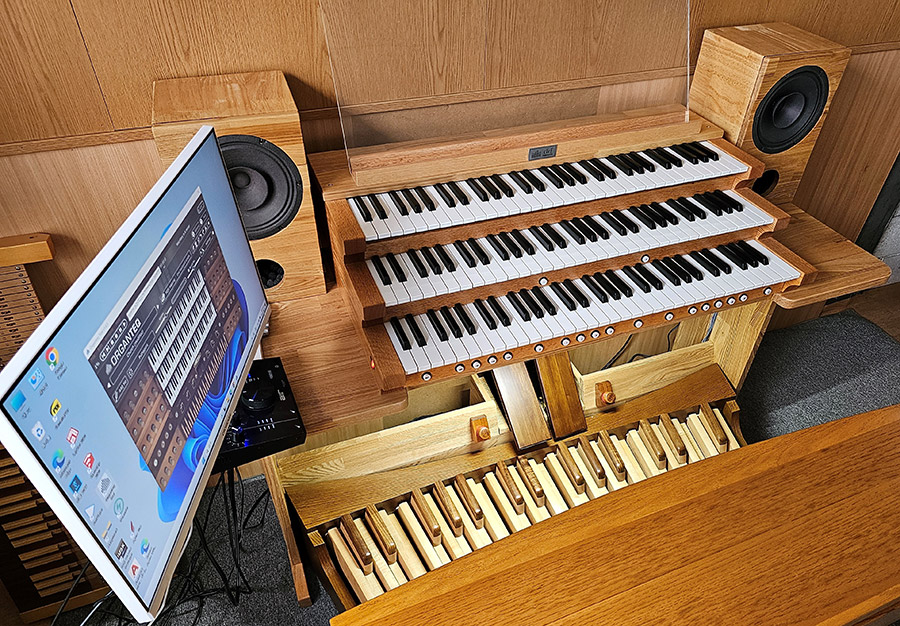

In [ ]:
import requests
from PIL import Image
from io import BytesIO

url = "http://organ-korea.co.kr/wp-content/uploads/2024/07/v-01.jpg"

response = requests.get(url) # 요청
response.raise_for_status() # 요청 실패시 에러

with open('image.jpg', 'wb') as f:
  f.write(response.content)


# 이미지 확인
image = Image.open(BytesIO(response.content))
image


In [ ]:
client = OpenAI()

def analyze_image_with_text(image_url, prompt):
  try:
    response = client.chat.completions.create(
        model="gpt-4o",
        messages = [
            {
              "role": "user",
              # ★멀티모달 입력의 핵심을 content 리스트!
              "content": [
                  {"type": "text", "text": prompt},
                  {
                      "type": "image_url",
                      "image_url": {
                          "url": image_url,
                      },
                  },
              ],
            },
        ],
    )

    return response.choices[0].message.content

  except Exception as e:
    return f"에러 발생: {e}"

image_link = url
user_prompt = "이 이미지 속의 악기에 대해 설명해 줘"

result = analyze_image_with_text(image_link, user_prompt)

result


'이 이미지 속의 악기는 전자 오르간입니다. 전용 소프트웨어와 스피커가 함께 세트로 보이는 것으로 보아 디지털 방식으로 오르간 소리를 내는 악기로 보입니다. \n\n전자 오르간은 파이프 오르간과 달리 전자 기술을 사용해 소리를 생성하며, 공간 제약 없이 다양한 음색을 구현할 수 있는 특징이 있습니다. 이미지를 보면, 여러 개의 건반(매뉴얼)과 발로 연주하는 페달이 보이며, 이는 전통적인 오르간의 구조를 모방한 것입니다. 주로 교회 음악이나 클래식 음악에서 사용됩니다.'

In [ ]:
# 인터넷 url 이 아닌  내 로컬 파일을 보내려면?  이미지를 base64 인코딩 문자열로 변환해서 보내야 한다

import base64

def encode_image(image_path):
  with open(image_path, "rb") as f:
      return base64.b64encode(f.read()).decode('utf-8')


In [ ]:
client = OpenAI()

def analyze_image_with_text(image_file, prompt):

  base64_image = encode_image(image_file)

  try:
    response = client.chat.completions.create(
        model="gpt-4o",
        messages = [
            {
              "role": "user",
              # ★멀티모달 입력의 핵심을 content 리스트!
              "content": [
                  {"type": "text", "text": prompt},
                  {
                      "type": "image_url",
                      "image_url": {
                          "url": f"data:image/jpeg;base64,{base64_image}",
                          # 형식: data:{mime_type};base64,{base64_string}
                      },
                  },
              ],
            },
        ],
        max_tokenx=500,  # 답변길이 제한.
    )

    return response.choices[0].message.content

  except Exception as e:
    return f"에러 발생: {e}"

user_prompt = "이 이미지 속의 악기에 대해 설명해 줘"

result = analyze_image_with_text("image.jpg", user_prompt)

result


'이 이미지 속 악기는 전자 오르간입니다. 이 오르간은 여러 층의 건반으로 구성되어 있으며, 각 층의 건반은 다른 음색을 조정할 수 있게 해줍니다. 보통 전통적인 파이프 오르간의 소리를 디지털 방식으로 구현하여 연주할 수 있으며, 페달보드도 있어 발로 저음을 연주할 수 있습니다. 스피커가 장착되어 있어 소리를 외부로 출력할 수 있으며, 모니터가 연결되어 다양한 소프트웨어로 음색을 조정하거나 악보를 볼 수 있는 기능을 제공합니다. 이와 같은 전자 오르간은 교회나 연주회장에서 많이 사용됩니다.'

In [ ]:
# OpenAI API 는 한 파일달 최대 20MB 까지 허용.
# base64인코딩하면 원본대비 약 33% 증가...  (15M 이하를 추천.)

# Response API

In [ ]:
"""
✅ ChatCompletion API

  https://developers.openai.com/api/reference/chat-completions/overview

  ■ 주요기능
    •사용자 입력에 대한 직접적인 응답 생성
    •대화의 문맥을 개발자가 직접 관리

  ■ 문맥관리
    •개발자가 대화의 문맥을 직접 유지하고 각 요청시 이전 대화 내용을 함께 제공해야 함

  ■ 내장도구지원
    •기본적으로 내장 도구 지원 없음
    •함수 호출을 통해 외부 API 호출 가능

  ■ 사용편의성
    •간단한 상호작용에 적합
    •개발자가 문맥 관리와 도구 통합을 직접 구현해야 함

  ■ 상태관리
    •상태를 수동으로 관리

  ■ 출시및 지원현황
    •2026.1 현재 지속적으로 지원및 업데이트 중

✅ Response API

  https://developers.openai.com/api/reference/responses/overview

  ■ 주요기능
    •챗 컴플리션과 어시스턴트 API의 기능통합
    •서버에서 대화 상태 관리
    •웹 검색, 파일 검색, 컴퓨터 사용 등 내장도구 지원

  ■ 문맥관리
    •서버에서 대화 상태를 관리하여 개발자의 부담 감소
    •이전 대화와의 연속성 유지 가능

  ■ 내장도구지원
    •웹 검색, 파일 검색, 컴퓨터 사용 등 다양한 내장 도구 지원
    •도구 자동 선택 기능으로 필요 시에만 도구 호출

  ■ 사용편의성
    •챗 컴플리션 API의 간편함과 어시스턴트 API의 고급 기능을 결합
    •상태 관리와 도구 사용이 통합되어 개발자의 워크플로 단순화
    •스트리밍 응답 지원

  ■ 상태관리
    •이전 대화의 상태를 자동으로 유지 가능
    •대화의 연속성 유지가 용이

  ■ 출시및 지원현황
    •2026.1 현재 사용 가능하며, AI 에이전트 구축의 표준 API로 자리 잡고 있음
    •새로운 모델과 기능이 지속적으로 추가될 예정

"""
None

In [ ]:
client = OpenAI()

def get_response(prompt, model='gpt-5-mini'):
  response = client.responses.create(
      model=model,
      tools=[{"type": "web_search_preview"}],  # 기본 내장된 웹 검색 도구 활성화
      input=prompt,  # 사용자 입력
  )

  return response.output_text   # 텍스트 응답


prompt = """
https://developers.openai.com/api/reference/resources/responses/methods/create
를 읽어서 Responses API에 대해 요약 정리해주세요.
"""

output = get_response(prompt)

output


'요청하신 페이지(Responses API — Create)를 읽고 핵심만 간단히 정리했습니다. 주요 내용은 “POST /v1/responses”를 통해 모델에 입력을 보내고 완성(또는 스트리밍)된 결과를 받는 방식이며, 멀티모달 입력·툴(함수) 호출·구조화된 출력(JSON Schema) 등을 지원합니다. 아래 항목별 요약을 참고하세요.\n\n요약 — 핵심 포인트\n- 목적: 모델에 프롬프트(텍스트/메시지/이미지/파일 등)를 보내 응답(Response) 객체를 생성(동기/스트리밍)하는 엔드포인트입니다. ([developers.openai.com](https://developers.openai.com/api/reference/resources/responses/methods/create))  \n- 엔드포인트/인증: HTTP POST https://api.openai.com/v1/responses. 요청 헤더에 Authorization: Bearer $OPENAI_API_KEY 와 Content-Type: application/json 를 사용합니다. (문서 예시 포함). ([developers.openai.com](https://developers.openai.com/api/reference/resources/responses/methods/create))\n\n입력(Input) 형식\n- 간단한 문자열 입력("input": "text") 또는 메시지/아이템 배열 형태(각 item: role + content 리스트)로 보낼 수 있습니다. ([developers.openai.com](https://developers.openai.com/api/reference/resources/responses/methods/create))  \n- content 아이템 타입으로 input_text, input_image, input_file 등을 지원하며 이미지 URL / 파일 ID / base64 파일 데이터 등으로 멀티모달 입력이 가능합니다. ([developers.op

In [ ]:
# response API 를 사용한 streaming

import rich

def stream_response(prompt, model='gpt-5-mini'):
  with client.responses.stream(model=model,input=prompt) as stream:
    for event in stream:
      if "output_text" in event.type:  # 텍스트 출력 이벤트 인 경우.
          rich.print(event)


  rich.print(stream.get_final_response()) # 최종 응답 출력


stream_response("점심 메뉴 추천 해 주세요.")


ResponseTextDeltaEvent(
    content_index=0,
    delta='점',
    item_id='msg_0a374b0c64f624f70069d8ea9a574c8193a2b86be045a8cf5d',
    logprobs=[],
    output_index=1,
    sequence_number=6,
    type='response.output_text.delta',
    snapshot='점'
)

ResponseTextDeltaEvent(
    content_index=0,
    delta='심',
    item_id='msg_0a374b0c64f624f70069d8ea9a574c8193a2b86be045a8cf5d',
    logprobs=[],
    output_index=1,
    sequence_number=7,
    type='response.output_text.delta',
    snapshot='점심'
)

ResponseTextDeltaEvent(
    content_index=0,
    delta=' 메뉴',
    item_id='msg_0a374b0c64f624f70069d8ea9a574c8193a2b86be045a8cf5d',
    logprobs=[],
    output_index=1,
    sequence_number=8,
    type='response.output_text.delta',
    snapshot='점심 메뉴'
)

ResponseTextDeltaEvent(
    content_index=0,
    delta=' 추천',
    item_id='msg_0a374b0c64f624f70069d8ea9a574c8193a2b86be045a8cf5d',
    logprobs=[],
    output_index=1,
    sequence_number=9,
    type='response.output_text.delta',
    snapshot='점심 메뉴 추천'
)

ResponseTextDeltaEvent(
    content_index=0,
    delta='해',
    item_id='msg_0a374b0c64f624f70069d8ea9a574c8193a2b86be045a8cf5d',
    logprobs=[],
    output_index=1,
    sequence_number=10,
    type='response.output_text.delta',
    snapshot='점심 메뉴 추천해'
)

...

ResponseTextDeltaEvent(
    content_index=0,
    delta='게',
    item_id='msg_0a374b0c64f624f70069d8ea9a574c8193a2b86be045a8cf5d',
    logprobs=[],
    output_index=1,
    sequence_number=426,
    type='response.output_text.delta',
    snapshot='점심 메뉴 추천해 드릴게요. 혹시 알레르기나 채식, 매운 음식 여부 같은 선호가 있으면 알려주세요. 없다면
아래에서 골라보세요.\n\n- 한식\n  - 비빔밥: 채소·계란·고기 골고루, 든든하고 비교적 건강함\n  - 김치찌개 또는 
된장찌개: 밥과 찌개 한 그릇, 따뜻하고 포만감 있음\n  - 불고기 정식 또는 제육볶음: 고기 중심으로 힘나는 점심\n\n- 
분식/간편\n  - 김밥 + 떡볶이: 가볍게 먹기 좋고 배달도 쉬움\n  - 잔치국수 또는 칼국수: 부담 적고 따뜻함\n\n- 
일식/아시아\n  - 초밥 또는 규동: 깔끔하고 소량씩 즐기기 좋음\n  - 라멘: 진한 국물이 먹고 싶을 때\n\n- 서양식\n  - 
샌드위치(클럽/참치/치킨): 빠르고 간편, 포장용 적합\n  - 파스타(까르보나라/토마토): 다양하게 선택 가능\n  - 샐러드 
볼 + 단백질(치킨/연어): 가볍고 건강하게\n\n- 건강/다이어트\n  - 현미밥 + 구운채소 + 닭가슴살\n  - 
포케볼(생선·채소·현미): 신선하고 영양 균형 좋음\n\n- 특별 추천(날씨/기분)\n  - 비 오는 날: 순두부찌개, 칼칼한 국물 
음식\n  - 더운 날: 냉면 또는 비빔국수\n\n원하시는 분위기(가성비/건강/매운맛/채식 등)나 근처에서 바로 먹을지 
배달할지 알려주시면 더 맞춤으로 추천해 드릴게'
)

ResponseTextDeltaEvent(
    content_index=0,
    delta='요',
    item_id='msg_0a374b0c64f624f70069d8ea9a574c8193a2b86be045a8cf5d',
    logprobs=[],
    output_index=1,
    sequence_number=427,
    type='response.output_text.delta',
    snapshot='점심 메뉴 추천해 드릴게요. 혹시 알레르기나 채식, 매운 음식 여부 같은 선호가 있으면 알려주세요. 없다면
아래에서 골라보세요.\n\n- 한식\n  - 비빔밥: 채소·계란·고기 골고루, 든든하고 비교적 건강함\n  - 김치찌개 또는 
된장찌개: 밥과 찌개 한 그릇, 따뜻하고 포만감 있음\n  - 불고기 정식 또는 제육볶음: 고기 중심으로 힘나는 점심\n\n- 
분식/간편\n  - 김밥 + 떡볶이: 가볍게 먹기 좋고 배달도 쉬움\n  - 잔치국수 또는 칼국수: 부담 적고 따뜻함\n\n- 
일식/아시아\n  - 초밥 또는 규동: 깔끔하고 소량씩 즐기기 좋음\n  - 라멘: 진한 국물이 먹고 싶을 때\n\n- 서양식\n  - 
샌드위치(클럽/참치/치킨): 빠르고 간편, 포장용 적합\n  - 파스타(까르보나라/토마토): 다양하게 선택 가능\n  - 샐러드 
볼 + 단백질(치킨/연어): 가볍고 건강하게\n\n- 건강/다이어트\n  - 현미밥 + 구운채소 + 닭가슴살\n  - 
포케볼(생선·채소·현미): 신선하고 영양 균형 좋음\n\n- 특별 추천(날씨/기분)\n  - 비 오는 날: 순두부찌개, 칼칼한 국물 
음식\n  - 더운 날: 냉면 또는 비빔국수\n\n원하시는 분위기(가성비/건강/매운맛/채식 등)나 근처에서 바로 먹을지 
배달할지 알려주시면 더 맞춤으로 추천해 드릴게요'
)

ResponseTextDeltaEvent(
    content_index=0,
    delta='.',
    item_id='msg_0a374b0c64f624f70069d8ea9a574c8193a2b86be045a8cf5d',
    logprobs=[],
    output_index=1,
    sequence_number=428,
    type='response.output_text.delta',
    snapshot='점심 메뉴 추천해 드릴게요. 혹시 알레르기나 채식, 매운 음식 여부 같은 선호가 있으면 알려주세요. 없다면
아래에서 골라보세요.\n\n- 한식\n  - 비빔밥: 채소·계란·고기 골고루, 든든하고 비교적 건강함\n  - 김치찌개 또는 
된장찌개: 밥과 찌개 한 그릇, 따뜻하고 포만감 있음\n  - 불고기 정식 또는 제육볶음: 고기 중심으로 힘나는 점심\n\n- 
분식/간편\n  - 김밥 + 떡볶이: 가볍게 먹기 좋고 배달도 쉬움\n  - 잔치국수 또는 칼국수: 부담 적고 따뜻함\n\n- 
일식/아시아\n  - 초밥 또는 규동: 깔끔하고 소량씩 즐기기 좋음\n  - 라멘: 진한 국물이 먹고 싶을 때\n\n- 서양식\n  - 
샌드위치(클럽/참치/치킨): 빠르고 간편, 포장용 적합\n  - 파스타(까르보나라/토마토): 다양하게 선택 가능\n  - 샐러드 
볼 + 단백질(치킨/연어): 가볍고 건강하게\n\n- 건강/다이어트\n  - 현미밥 + 구운채소 + 닭가슴살\n  - 
포케볼(생선·채소·현미): 신선하고 영양 균형 좋음\n\n- 특별 추천(날씨/기분)\n  - 비 오는 날: 순두부찌개, 칼칼한 국물 
음식\n  - 더운 날: 냉면 또는 비빔국수\n\n원하시는 분위기(가성비/건강/매운맛/채식 등)나 근처에서 바로 먹을지 
배달할지 알려주시면 더 맞춤으로 추천해 드릴게요.'
)

ResponseTextDoneEvent[TypeVar](
    content_index=0,
    item_id='msg_0a374b0c64f624f70069d8ea9a574c8193a2b86be045a8cf5d',
    logprobs=[],
    output_index=1,
    sequence_number=429,
    text='점심 메뉴 추천해 드릴게요. 혹시 알레르기나 채식, 매운 음식 여부 같은 선호가 있으면 알려주세요. 없다면 
아래에서 골라보세요.\n\n- 한식\n  - 비빔밥: 채소·계란·고기 골고루, 든든하고 비교적 건강함\n  - 김치찌개 또는 
된장찌개: 밥과 찌개 한 그릇, 따뜻하고 포만감 있음\n  - 불고기 정식 또는 제육볶음: 고기 중심으로 힘나는 점심\n\n- 
분식/간편\n  - 김밥 + 떡볶이: 가볍게 먹기 좋고 배달도 쉬움\n  - 잔치국수 또는 칼국수: 부담 적고 따뜻함\n\n- 
일식/아시아\n  - 초밥 또는 규동: 깔끔하고 소량씩 즐기기 좋음\n  - 라멘: 진한 국물이 먹고 싶을 때\n\n- 서양식\n  - 
샌드위치(클럽/참치/치킨): 빠르고 간편, 포장용 적합\n  - 파스타(까르보나라/토마토): 다양하게 선택 가능\n  - 샐러드 
볼 + 단백질(치킨/연어): 가볍고 건강하게\n\n- 건강/다이어트\n  - 현미밥 + 구운채소 + 닭가슴살\n  - 
포케볼(생선·채소·현미): 신선하고 영양 균형 좋음\n\n- 특별 추천(날씨/기분)\n  - 비 오는 날: 순두부찌개, 칼칼한 국물 
음식\n  - 더운 날: 냉면 또는 비빔국수\n\n원하시는 분위기(가성비/건강/매운맛/채식 등)나 근처에서 바로 먹을지 
배달할지 알려주시면 더 맞춤으로 추천해 드릴게요.',
    type='response.output_text.done',
    parsed=None
)

ParsedResponse[TypeVar](
    id='resp_0a374b0c64f624f70069d8ea96528481938ce1f0e7ae7a2934',
    created_at=1775823510.0,
    error=None,
    incomplete_details=None,
    instructions=None,
    metadata={},
    model='gpt-5-mini-2025-08-07',
    object='response',
    output=[
        ResponseReasoningItem(
            id='rs_0a374b0c64f624f70069d8ea96ce9081938b5106d0d1c799b4',
            summary=[],
            type='reasoning',
            content=None,
            encrypted_content=None,
            status=None
        ),
        ParsedResponseOutputMessage[TypeVar](
            id='msg_0a374b0c64f624f70069d8ea9a574c8193a2b86be045a8cf5d',
            content=[
                ParsedResponseOutputText[TypeVar](
                    annotations=[],
                    text='점심 메뉴 추천해 드릴게요. 혹시 알레르기나 채식, 매운 음식 여부 같은 선호가 있으면 
알려주세요. 없다면 아래에서 골라보세요.\n\n- 한식\n  - 비빔밥: 채소·계란·고기 골고루, 든든하고 비교적 건강함\n  - 
김치찌개 또는 된장찌개: 밥과 찌개 한 그릇, 따뜻하고 포만감 있음\n  - 불고기 정식 또는 제육볶음: 고기 중심으로 
힘나는 점심\n\n- 분식/간편\n  - 김밥 + 떡볶이: 가볍게 먹기 좋고 배달도 쉬움\n  - 잔치국수 또는 칼국수: 부담 적고 
따뜻함\n\n- 일식/아시아\n  - 초밥 또는 규동: 깔끔하고 소량씩 즐기기 좋음\n  - 라멘: 진한 국물이 먹고 싶을 때\n\n- 
서양식\n  - 샌드위치(클럽/참치/치킨): 빠르고 간편, 포장용 적합\n  - 파스타(까르보나라/토마토): 다양하게 선택 가능\n
- 샐러드 볼 + 단백질(치킨/연어): 가볍고 건강하게\n\n- 건강/다이어트\n  - 현미밥 + 구운채소 + 닭가슴살\n  - 
포케볼(생선·채소·현미): 신선하고 영양 균형 좋음\n\n- 특별 추천(날씨/기분)\n  - 비 오는 날: 순두부찌개, 칼칼한 국물 
음식\n  - 더운 날: 냉면 또는 비빔국수\n\n원하시는 분위기(가성비/건강/매운맛/채식 등)나 근처에서 바로 먹을지 
배달할지 알려주시면 더 맞춤으로 추천해 드릴게요.',
                    type='output_text',
                    logprobs=[],
                    parsed=None
                )
            ],
            role='assistant',
            status='completed',
            type='message',
            phase=None
        )
    ],
    parallel_tool_calls=True,
    temperature=1.0,
    tool_choice='auto',
    tools=[],
    top_p=1.0,
    background=False,
    completed_at=1775823520.0,
    conversation=None,
    max_output_tokens=None,
    max_tool_calls=None,
    previous_response_id=None,
    prompt=None,
    prompt_cache_key=None,
    prompt_cache_retention=None,
    reasoning=Reasoning(effort='medium', generate_summary=None, summary=None),
    safety_identifier=None,
    service_tier='default',
    status='completed',
    text=ResponseTextConfig(format=ResponseFormatText(type='text'), verbosity='medium'),
    top_logprobs=0,
    truncation='disabled',
    usage=ResponseUsage(
        input_tokens=13,
        input_tokens_details=InputTokensDetails(cached_tokens=0),
        output_tokens=680,
        output_tokens_details=OutputTokensDetails(reasoning_tokens=192),
        total_tokens=693
    ),
    user=None,
    frequency_penalty=0.0,
    presence_penalty=0.0,
    store=True
)

# Embedding

In [ ]:

def get_embedding(text, model='text-embedding-3-small'):
  text = text.replace("\n", " ")

  response = client.embeddings.create(
      input = [text],
      model=model,
          # text-embedding-3-small: 속도가 빠르고 비용이 저렴하여 일반적인 용도로 추천합니다.
          # text-embedding-3-large: 더 정교한 의미 파악이 필요할 때 사용하며, 벡터 차원이 더 큽니다.
          # text-embedding-ada-002: 예전 모델이지만 여전히 널리 사용됩니다.
  )

  return response.data[0].embedding  # 결괏값 (벡터 리스트)

my_text = "임베딩은 인공지능이 언어를 이해하는 핵심 기술입니다."
embedding_vector = get_embedding(my_text)

print(f"텍스트: {my_text}")
print(f"벡터 길이: {len(embedding_vector)}")
print(f"벡터샘플(첫 5개): {embedding_vector[:5]}")


텍스트: 임베딩은 인공지능이 언어를 이해하는 핵심 기술입니다.
벡터 길이: 1536
벡터샘플(첫 5개): [-0.004184722900390625, 0.031463623046875, 0.0232696533203125, 0.0127410888671875, 0.0160980224609375]


# STT (Speech To Text)

In [ ]:
import requests

url = "https://www.dropbox.com/scl/fi/qm3bdfimzhu9p0vdtgkqz/chunk_7.mp3?rlkey=o3r82yvkloe483esbq0eri72r&st=fbh8qtqm&dl=1"
response = requests.get(url)
response.raise_for_status()  # 요청 실패 시 에러

with open('audio.mp3', 'wb') as f:
    f.write(response.content)  # 일단 저장

In [ ]:
def transcribe_audio(file_path):
  with open(file_path, "rb") as f:

    transcript = client.audio.transcriptions.create(
        model='whisper-1',
        file=f,
        response_format="text",
    )

  return transcript

result = transcribe_audio('audio.mp3')

result


"And now you're scared that if you don't be that person, you will lose it. And I just wouldn't want to live that way because then you are just acting and not being. It's like, you think that having the success, proving yourself should make you more courageous, less risk averse, because now you've done it. But in fact, the opposite is true, right? This is where courage and discipline are related. It's the opposite. Now you have something to lose. Now you don't want to change, go in a different direction because the expectation is set with the first one. So you imagine how scary it is, Tiger Woods. You're like, you're the best swing in golf. And you're like, but I think it could be better, but I'm gonna have to go have a bad swing for months to get to the other side of that. And so the ability to say, I decide whether I'm successful or not, not the external results. And that's why I'm willing to go down this detour, try things differently, do this. That is that sort of key skill. And cou

# DALL E 3  이미지 생성

In [ ]:

def generate_image_by_text(prompt):
  try:
    response = client.images.generate(
        model="dall-e-3", # 또는 최신 모델인 "gpt-image-1.5" 사용 가능
                  # dall-e-3는 뛰어난 묘사력을 보여주며,
                  # 최신 gpt-image 시리즈는 속도와 텍스트 렌더링 성능이 더 강화되었습니다.

        prompt = prompt,

        size="1024x1024",
        quality="standard",  # 'standard', 'hd'

        n=1,  # 생성할 이미지 개수 (dall-e 3 는 1개만 지원)
    )

    # 생성된 이미지는 OpenAI 서버에 임시로 저장되며, 약 1시간 동안 유효한 URL을 제공합니다.
    image_url = response.data[0].url
    print(f"생성된 이미지 URL: {image_url}")
    return image_url

  except Exception as e:
    return f"에러 발생: {e}"



# 실행 예시
my_prompt = """
  눈 덮인 산을 배경으로 오렌지색 목도리를 두른 귀여운 수달이 코코아를 마시는 모습
  """
url = generate_image_by_text(my_prompt)
url

생성된 이미지 URL: https://oaidalleapiprodscus.blob.core.windows.net/private/org-kP37rM5FQm9vDTLVM9f0ycCW/user-KwV5ELRWx1SFAcAEsMdXKcIy/img-iKWkTUaUz6HGsGUc6ivN8L0F.png?st=2026-04-10T11%3A37%3A20Z&se=2026-04-10T13%3A37%3A20Z&sp=r&sv=2026-02-06&sr=b&rscd=inline&rsct=image/png&skoid=35890473-cca8-4a54-8305-05a39e0bc9c3&sktid=a48cca56-e6da-484e-a814-9c849652bcb3&skt=2026-04-10T00%3A35%3A36Z&ske=2026-04-11T00%3A35%3A36Z&sks=b&skv=2026-02-06&sig=qHOOpvwbAmJ/lZ65duWNbl5R1gofEVPhTxw9w/IdOYw%3D


'https://oaidalleapiprodscus.blob.core.windows.net/private/org-kP37rM5FQm9vDTLVM9f0ycCW/user-KwV5ELRWx1SFAcAEsMdXKcIy/img-iKWkTUaUz6HGsGUc6ivN8L0F.png?st=2026-04-10T11%3A37%3A20Z&se=2026-04-10T13%3A37%3A20Z&sp=r&sv=2026-02-06&sr=b&rscd=inline&rsct=image/png&skoid=35890473-cca8-4a54-8305-05a39e0bc9c3&sktid=a48cca56-e6da-484e-a814-9c849652bcb3&skt=2026-04-10T00%3A35%3A36Z&ske=2026-04-11T00%3A35%3A36Z&sks=b&skv=2026-02-06&sig=qHOOpvwbAmJ/lZ65duWNbl5R1gofEVPhTxw9w/IdOYw%3D'

In [ ]:
import requests

def save_image(url, filename="generated_image.png"):
    img_data = requests.get(url).content
    with open(filename, 'wb') as handler:
        handler.write(img_data)
    print(f"이미지가 {filename}으로 저장되었습니다.")

save_image(url)

이미지가 generated_image.png으로 저장되었습니다.
